
========🕷️ STEP 1: Crawling from website...========
Successful crawl on 2026-10-07 00:58:18
Total records obtained: 1067371

=== 🧩 DATA STRUCTURE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1067371 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

=========== 📊  STEP 2: DATA UNDERSTANDING =========== 

===1️⃣ 2.1: Duplicate record ===
Total duplicate records: 34335
Percentage of duplicate 

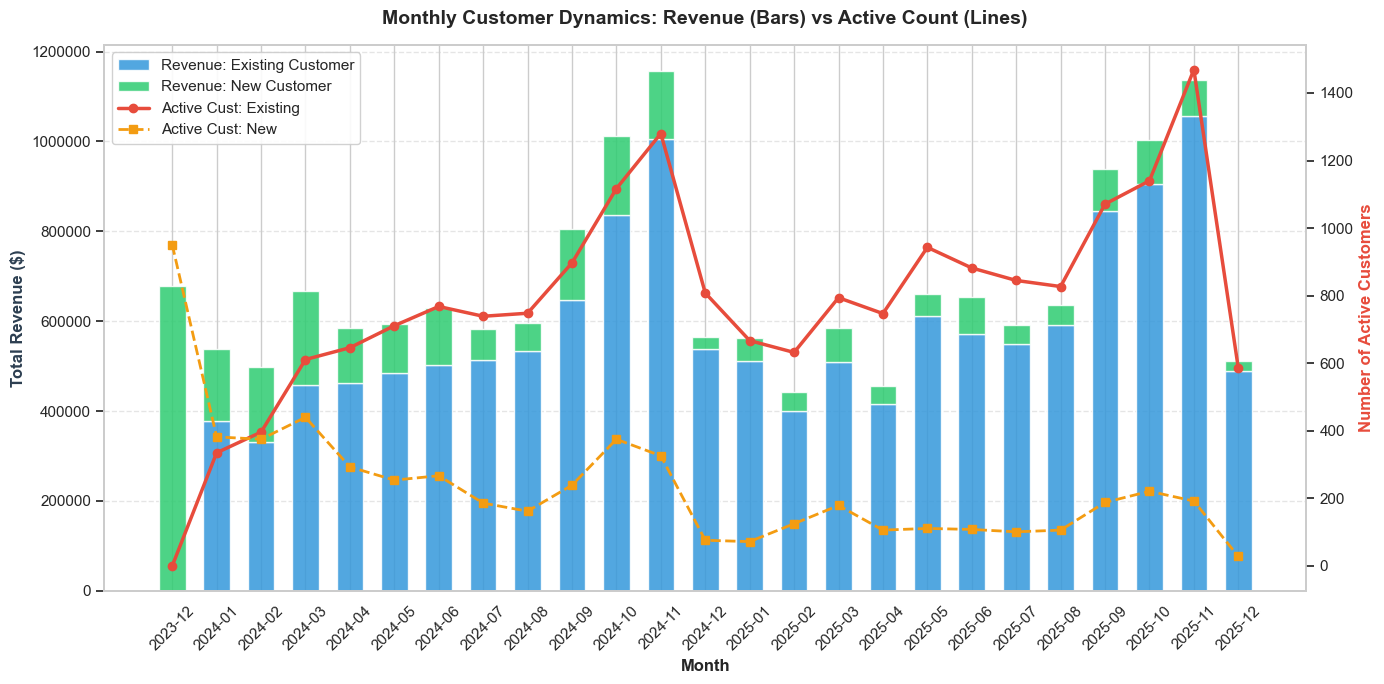


===🧠 EXECUTIVE BUSINESS INSIGHTS summary ===========
💡1. Clean data scale ready for churn analysis: 776,922 purchases from 5,863 customers across 4,623 different products .
💡2. On average, 786 returning customers were active each month accounting for 77.0% of the average monthly active customer base.
💡3. Seasonality: Average monthly revenue in Q4 (October–December) was 41.6% higher than in non-Q4 months.
💡4.Geography and catalog diversity
 • 90.1 % of valid purchases come from United Kingdom
 • Catalog Diversity:  Customers purchased an average of 82.0 unique products.

 SUCCESSFULLY EXPORTED CLEANED DATASETS FOR TEAM MEMBERS!


In [1]:
import pandas as pd
import numpy as np
import time
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
# 🔎 STEP 1: SIMULATING DATA CRAWLING
# 1.1: 🕷️ Crawl function
def crawl_data(file_path):
    print("\n========🕷️ STEP 1: Crawling from website...========")
    time.sleep(2)  # Stimulate craw delay

    # Read file
    df_crawled = pd.read_parquet(file_path)

    # Print log like real crawl
    print(f"Successful crawl on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total records obtained: {len(df_crawled)}")

    # Shift original transaction datas by 14 years for simulation
    df_crawled['InvoiceDate'] = pd.to_datetime(df_crawled['InvoiceDate']) + pd.DateOffset(years=14)

    return df_crawled
# 1.2:📞 Call function and save raw data to dataframe
df=crawl_data("../data/raw/online_retail_II.parquet")
print("\n=== 🧩 DATA STRUCTURE ===")
df.info()

# 📊 STEP 2: DATA UNDERSTANDING
print("\n=========== 📊  STEP 2: DATA UNDERSTANDING =========== ")
# 2.1: Check duplicate record
print("\n===1️⃣ 2.1: Duplicate record ===")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate records: {duplicate_count}")
print(f"Percentage of duplicate records: {duplicate_count / len(df):.2%}")
# 2.2: Check Missing Value
print("\n===2️⃣ 2.2: Missing value ===")
print(df.isnull().sum())
# 2.3: Numerical Statistics
print('\n===3️⃣ 2.3: Numerical summary ===')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print(df[['Quantity', 'Price']].describe())
# 2.4: Check Non-Product StockCodes
# Identify non product code
non_product_pattern = r'^(?:POST|D|M|BANK CHARGES|PADS|DOT|CRUK|TEST|AMAZONFEE)'
non_product_records = df[df['StockCode'].astype(str).str.contains(non_product_pattern, case=False, regex=True)]
print('\n===4️⃣ 2.4 Non-product stockcode check ===')
print(f'Total non-product records found: {len(non_product_records)}')
print('Unique non-product codes:'f" {non_product_records['StockCode'].unique()}")

# 2.5: Check cancelled sales
print("\n===5️⃣ 2.5: Cancelled sales check ===")
# 2.5.1: Count records based on invoice ID, start with letter 'C'
c_count = df['Invoice'].astype(str).str.startswith('C').sum()
# 2.5.2: Count records based on quantity
# a: Count records with quantity==0
zero_qty_count = (df['Quantity'] == 0).sum()
# b: Count records with quantity <0
negative_qty_count = (df['Quantity'] < 0).sum()
# 2.5.3 Total records with quantity <0 but invoice does not start with code 'C'
non_c_flag_negative_quantity = df[(df['Quantity'] < 0) & (~df['Invoice'].astype(str).str.startswith('C'))]
# 2.5.4: Total records with invoice start with letter 'C' but quantity >0
c_flag_positive_quantity = df[(df['Invoice'].astype(str).str.startswith('C')) & (df['Quantity'] > 0)]
# 2.5.5: Consider all records with either Cancelled invoice code 'C' or Quantity < 0 as cancelled sales
cancelled_sales = df[(df['Invoice'].astype(str).str.startswith('C')) | (df['Quantity'] < 0)]
# 2.5.6: Display:
print(f"Total records with invoice code cancelled: {c_count}")
print(f"Total quantity record with value == 0: {zero_qty_count}") # Records are not valid transactions.
print(f"Total records with quantity < 0: {negative_qty_count}")
print(f"Total records with quantity < 0 but invoice code differs from C: {len(non_c_flag_negative_quantity)}")
print(f"Total records with invoice code C but quantity > 0: {len(c_flag_positive_quantity)}")
print(f"Total cancelled sales records: {len(cancelled_sales)}")
print(f"Percentage of cancelled sales: {len(cancelled_sales) / len(df):.2%}")

# # 2.6: Check price abnormality (<=0)
print("\n===6️⃣ 2.6: Price check ===")
""" Understanding Zero-Price Records (some special cases, price ==0 may mean free item or
 promotional/special transactions need to understand the context before filtering)"""
zero = df[df['Price'].eq(0)]
paid_invoices = df.groupby('Invoice')['Price'].transform(lambda x: (x > 0).any())
gift = zero.index.isin(df.index[paid_invoices])
print(f"Total Price == 0 records: {len(zero):,}")
print(f"Potential customer activity (gift/free item): {gift.sum():,}")

# 🧹 STEP 3: DATA CLEANING
print('\n====================🧹 STEP 3: DATA CLEANING ====================')
initial_rows = len(df)
df_cleaned = df.copy()

# 3.1: Remove Duplicate records
df_cleaned = df_cleaned.drop_duplicates()
print(f'3.1. Removed {initial_rows - len(df_cleaned)} duplicate rows.')

# 3.2: Remove Missing Customer ID
rows_before_id = len(df_cleaned)
df_cleaned = df_cleaned.dropna(subset=['Customer ID'])
print( f'3.2. Removed {rows_before_id - len(df_cleaned)} rows with missing Customer ID.')

# 3.3: Remove non product code records:
# a) Create filter mask
non_product_mask = df_cleaned['StockCode'].astype(str).str.contains(non_product_pattern, case=False, regex=True)
# b) Separate no product code to a different df
non_product_df = df_cleaned[non_product_mask].copy()
# c) Only keep the data with valid product code.
df_cleaned = df_cleaned[~non_product_mask].copy()
print(f'3.3. Removed {len(non_product_df)} non-product records.')

# 3.4: Separate Cancelled purchases from Valid Purchases
# Save cancelled purchases for later use
cancelled_df = df_cleaned[(df_cleaned['Invoice'].astype(str).str.startswith('C'))|(df_cleaned['Quantity'] < 0)].copy()
# Keep only valid positive transactions for RFM & Sales calculation
valid_sales_df = df_cleaned[(~df_cleaned['Invoice'].astype(str).str.startswith('C')) & (df_cleaned['Quantity'] > 0)].copy()
print(f'3.4. Cancelled/returned records: {len(cancelled_df):,}.')
print(f'    Valid sales records: {len(valid_sales_df):,}.')

# 3.5: Handle price anomalies
rows_before_price = len(valid_sales_df)
# Keep Price == 0 as customer activity, price> 0 as valid transaction, only remove only negative prices
valid_sales_df = valid_sales_df[valid_sales_df['Price'] >= 0].copy()
zero_price_count = (valid_sales_df['Price'] == 0).sum()
print(f'3.5. Removed {rows_before_price - len(valid_sales_df)} records with Price < 0 (already removed records with Null Customer ID).')
print(f'    Retained {zero_price_count:,} zero-price records as customer activity.')

# 3.6: Clean summary
print('\n👉Cleaning summary ===')
print(f'Initial total records: {initial_rows}')
print(
    f'Cleaned valid sales records (for RFM/Monetary): {len(valid_sales_df)}'
)
print(f'Cleaned cancelled records (for Return Rate): {len(cancelled_df)}')
print(
    'Total retained records:'
    f' {len(valid_sales_df) + len(cancelled_df)}'
    f' ({(len(valid_sales_df) + len(cancelled_df)) / initial_rows:.2%})'
)
# a) Filter out missing Customer IDs on raw data first to allow groupby on raw data
raw_valid_id = df.dropna(subset=['Customer ID'])
raw_orders = raw_valid_id.groupby('Customer ID')['Invoice'].nunique()

total_raw_cust = len(raw_orders)
raw_one_time = (raw_orders == 1).sum()
raw_repeat = (raw_orders > 1).sum()

# b) Compute customer metrics on CLEANED DATA (valid_sales_df)
clean_orders = valid_sales_df.groupby('Customer ID')['Invoice'].nunique()
total_clean_cust = len(clean_orders)
clean_one_time = (clean_orders == 1).sum()
clean_repeat = (clean_orders > 1).sum()

# c) Print Comparison Table
print('\n👉Cleaned data vs Raw data')
print(f"{'METRIC':<30} | {'RAW DATA':<15} | {'CLEANED DATA':<15} | {'IMPACT':<15}")
print('-' * 82)
print(
    f"{'Total Unique Customers':<30} | {total_raw_cust:<15,d} |"
    f' {total_clean_cust:<15,d} | {total_clean_cust - total_raw_cust:<+15,d}'
)
print(
    f"{'One-time Buyers (1 order)':<30} | {raw_one_time:<15,d} |"
    f' {clean_one_time:<15,d} | {clean_one_time - raw_one_time:<+15,d}'
)
print(
    f"{'% One-time Buyers':<30} | {raw_one_time/total_raw_cust:<15.2%} |"
    f' {clean_one_time/total_clean_cust:<15.2%} |'
    f' {(clean_one_time/total_clean_cust) - (raw_one_time/total_raw_cust):<+15.2%}'
)
print(
    f"{'Repeat Buyers (>1 orders)':<30} | {raw_repeat:<15,d} |"
    f' {clean_repeat:<15,d} | {clean_repeat - raw_repeat:<+15,d}'
)
print(
    f"{'% Repeat Buyers':<30} | {raw_repeat/total_raw_cust:<15.2%} |"
    f' {clean_repeat/total_clean_cust:<15.2%} |'
    f' {(clean_repeat/total_clean_cust) - (raw_repeat/total_raw_cust):<+15.2%}'
)
print('-' * 82)

#📊 STEP 4: EXPLORATORY DATA ANALYSIS
print('\n 📊======= STEP 4: DEEP EDA ============')

sns.set_theme(style='whitegrid')

# 4.1. Create TotalSales and YearMonth field
valid_sales_df['TotalSales'] = (valid_sales_df['Quantity'] * valid_sales_df['Price'])
valid_sales_df['YearMonth'] = valid_sales_df['InvoiceDate'].dt.to_period('M')

# 4.2. BỔ SUNG: Identify first purchase and label customer type
if 'FirstMonth' in valid_sales_df.columns:
  valid_sales_df = valid_sales_df.drop(columns=['FirstMonth'])

first_purchase = (
    valid_sales_df.groupby('Customer ID')['YearMonth']
    .min()
    .reset_index(name='FirstMonth')
)
valid_sales_df = valid_sales_df.merge(
    first_purchase, on='Customer ID', how='left'
)

valid_sales_df['CustomerType'] = np.where(
    valid_sales_df['YearMonth'] == valid_sales_df['FirstMonth'],
    'New Customer',
    'Existing Customer',
)
# 4.3: Dual axis chart: REVENUE (BAR) & CUSTOMERS (LINE)
# a. Data preparation for chart
monthly_cust_type = (
    valid_sales_df.groupby(['YearMonth', 'CustomerType'])['Customer ID']
    .nunique()
    .unstack(fill_value=0)
)
monthly_rev_type = (
    valid_sales_df.groupby(['YearMonth', 'CustomerType'])['TotalSales']
    .sum()
    .unstack(fill_value=0)
)

months = monthly_rev_type.index.astype(str)

# b. Create the only figure
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- Left axis (AX1): Revenue column ($ REVENUE) ---
bars1 = ax1.bar(
    months,
    monthly_rev_type['Existing Customer'],
    label='Revenue: Existing Customer',
    color='#3498db',
    alpha=0.85,
    width=0.6,
)
bars2 = ax1.bar(
    months,
    monthly_rev_type['New Customer'],
    bottom=monthly_rev_type['Existing Customer'],
    label='Revenue: New Customer',
    color='#2ecc71',
    alpha=0.85,
    width=0.6,
)

ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel(
    'Total Revenue ($)', fontsize=12, fontweight='bold', color='#2c3e50'
)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.ticklabel_format(style='plain', axis='y')
# --- Right axix (AX2): Number of customers (active ones) ---
ax2 = ax1.twinx()

line1 = ax2.plot(
    months,
    monthly_cust_type['Existing Customer'],
    color='#e74c3c',
    marker='o',
    linewidth=2.5,
    label='Active Cust: Existing',
)
line2 = ax2.plot(
    months,
    monthly_cust_type['New Customer'],
    color='#f39c12',
    marker='s',
    linewidth=2,
    linestyle='--',
    label='Active Cust: New',
)

ax2.set_ylabel(
    'Number of Active Customers',
    fontsize=12,
    fontweight='bold',
    color='#e74c3c',
)
ax2.grid(False)

# --- Add legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
)

plt.title(
    'Monthly Customer Dynamics: Revenue (Bars) vs Active Count (Lines)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.show()

# # -------------------------------------------------------------------------
# # 4.4: Business Insight Summary
# # -------------------------------------------------------------------------

print('\n===🧠 EXECUTIVE BUSINESS INSIGHTS summary ===========')

# 💡 4.4 1. Overview: N transactions, M customers, P products
total_tx = len(valid_sales_df)
total_cust = valid_sales_df['Customer ID'].nunique()
total_prod = valid_sales_df['StockCode'].nunique()

print(
    f'💡1. Clean data scale ready for churn analysis: {total_tx:,} purchases from'
    f' {total_cust:,} customers across {total_prod:,} different products .'
)

# 💡 4.4.2. Average monthly number of repeat customers
monthly_repeat_cust = (
    valid_sales_df.groupby(['YearMonth', 'CustomerType'])['Customer ID']
    .nunique()
    .unstack(fill_value=0)
)
avg_repeat_cust_monthly = monthly_repeat_cust['Existing Customer'].mean()
avg_active_cust_monthly = (
    monthly_repeat_cust['New Customer']
    + monthly_repeat_cust['Existing Customer']
).mean()
avg_repeat_pct = (avg_repeat_cust_monthly / avg_active_cust_monthly) * 100

print(
    f'💡2. On average, {avg_repeat_cust_monthly:.0f} returning customers were active each month'
    f' accounting for {avg_repeat_pct:.1f}% of the average monthly active customer base.'
)

# 💡4.4.3. Year-end shopping trends (Q4/October, November, December season vs. Remaining months)
valid_sales_df['Month_Num'] = valid_sales_df['InvoiceDate'].dt.month
q4_revenue_monthly_avg = valid_sales_df[
    valid_sales_df['Month_Num'].isin([10, 11, 12])
].groupby('YearMonth')['TotalSales'].sum().mean()
non_q4_revenue_monthly_avg = valid_sales_df[
    ~valid_sales_df['Month_Num'].isin([10, 11, 12])
].groupby('YearMonth')['TotalSales'].sum().mean()

seasonality_lift = (
    (q4_revenue_monthly_avg - non_q4_revenue_monthly_avg)
    / non_q4_revenue_monthly_avg
) * 100

print(
    f'💡3. Seasonality: Average monthly revenue in Q4 '
    f'(October–December) was {seasonality_lift:.1f}% higher '
    f'than in non-Q4 months.'
) #
# Customer purchasing activity varies across months.
# Seasonal patterns should therefore be considered when defining
# the inactivity period for churn labeling.

# 💡4.4.4. Behavioral Patterns: Geography, Catalog & Purchase Rhythm
top_country = valid_sales_df['Country'].value_counts(normalize=True).index[0]
top_country_pct = (
    valid_sales_df['Country'].value_counts(normalize=True).iloc[0] * 100
)

# Diversity of products
skus_per_cust = valid_sales_df.groupby('Customer ID')['StockCode'].nunique()
avg_skus_per_cust = skus_per_cust.mean()

print(
    '💡4.Geography and catalog diversity'
)
print(
    f' • {top_country_pct:.1f} % of valid purchases come from {top_country}'
)
print(
    f' • Catalog Diversity:  Customers purchased an average of'
    f' {avg_skus_per_cust:.1f} unique products.'
)

# -------------------------------------------------------------------------
# 4.5: Export cleaned data for others to use on next step
# -------------------------------------------------------------------------
# End of 1st phrase, save cleaned data for other members to use
valid_sales_df.to_parquet('valid_sales_clean.parquet', index=False)
cancelled_df.to_parquet('cancelled_clean.parquet', index=False)
print('\n SUCCESSFULLY EXPORTED CLEANED DATASETS FOR TEAM MEMBERS!')